<a href="https://colab.research.google.com/github/neeshat/Data-Science/blob/main/Eighth_class.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Stopping unnecessary warnings**

In [104]:
import warnings
warnings.filterwarnings('ignore')

# **Installing required libraries**

In [105]:
!pip install numpy pandas matplot seaborn scikit-learn

# **Importing required libraries**

In [111]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, precision_score, recall_score, f1_score

# **Loading the dataset**

In [112]:
from google.colab import drive
drive.mount("/content/drive")
df = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/datasets/breast_cancer.csv")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [114]:
df.tail()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
564,926424,M,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,...,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115,NaN
565,926682,M,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,...,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637,NaN
566,926954,M,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,...,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820,NaN
567,927241,M,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,...,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400,NaN
568,92751,B,7.76,24.54,47.92,181.0,0.05263,0.04362,0.00000,0.00000,...,30.37,59.16,268.6,0.08996,0.06444,0.0000,0.0000,0.2871,0.07039,NaN


# **Operations on the Dataset**

In [34]:
# Performing label-encoding or mapping

df['diagnosis_numeric'] = df['diagnosis'].map({'M': 1, 'B': 0})

# Selecting important features

important_features = ['radius_mean', 'texture_mean', 'area_mean', 'smoothness_mean', 'compactness_mean']

# Taking inputs and outputs

X = df[important_features]
y = df['diagnosis_numeric']

# Checking shape of inputs and outputs

X.shape
y.shape


(569,)

# **Train Test Split**

In [108]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 20)

# Checking X_train and y_train shape

print(f"Size of X_train data: {X_train.shape}")
print(f"Size of y_train data: {y_train.shape}")
X_train.head()

Size of X_train data: (455, 5)
Size of y_train data: (455,)


,radius_mean,texture_mean,area_mean,smoothness_mean,compactness_mean
412,9.397,21.68,268.8,0.07969,0.06053
461,27.420,26.27,2501.0,0.10840,0.19880
532,13.680,16.33,575.5,0.09277,0.07255
495,14.870,20.21,680.9,0.09587,0.08345
13,15.850,23.95,782.7,0.08401,0.10020


# **Training DecisionTreeClassifier Model**

In [109]:
my_doctor = DecisionTreeClassifier(max_depth = 4, random_state = 20) # I tried with multiple depths such as 2,3,4,5, but 4 gives the highest accuracy
my_doctor.fit(X_train, y_train)

# Testing the model

prediction = my_doctor.predict(X_test)
accuracy = accuracy_score(y_test, prediction)
print(f"{accuracy*100:.1f}%")

if accuracy > 0.95:
  print("Wow Doctor")
elif accuracy > 0.90:
  print("Good Doctor")
elif accuracy > 0.80:
  print("Ok")
else:
  print("Bad, need more training")

90.4%
Good Doctor


# **Confusion matrix**

[[62  4]
 [ 7 41]]
Correct: 103
Incorrect: 11


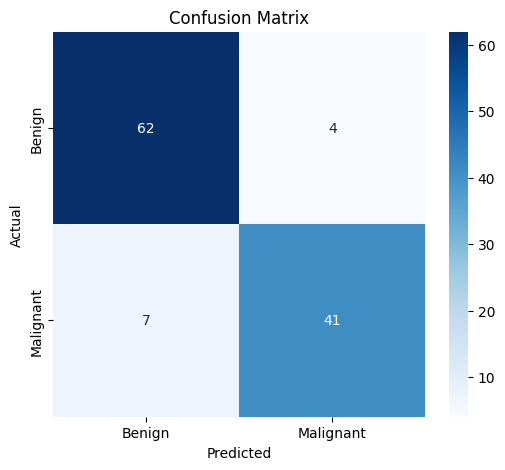

In [100]:
# Confusion matrix

cm = confusion_matrix(y_test, prediction)
print(cm)
print(f"Correct: {cm[0,0]+cm[1,1]}")
print(f"Incorrect: {cm[0,1]+cm[1,0]}")

# Plotting heatmap

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot = True, fmt = 'd', cmap='Blues', xticklabels = ['Benign', 'Malignant'], yticklabels = ['Benign', 'Malignant'])
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# **Calculating performance metrics**


In [110]:
precision = precision_score(y_test, prediction)
recall = recall_score(y_test, prediction)
f1 = f1_score(y_test, prediction)

# Showing them

print(f"Accuracy: {accuracy:.2f}")
print(f"Precision: {precision:.2f}")
print(f"Recall: {recall:.2f}")
print(f"F1 Score: {f1:.2f}")


Accuracy: 0.90
Precision: 0.91
Recall: 0.85
F1 Score: 0.88


# **Plotting performance metrics**

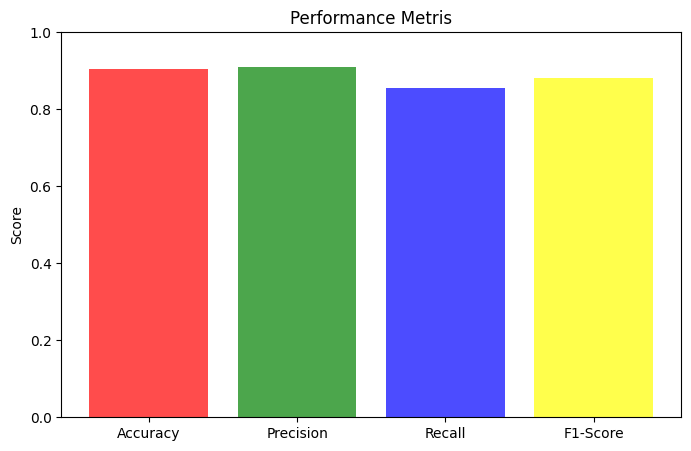

In [103]:
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
values = [accuracy, precision, recall, f1]

plt.figure(figsize=(8,5))
plt.title("Performance Metris")
plt.bar(metrics, values, color = ['red', 'green', 'blue', 'yellow'], alpha = 0.7)
plt.ylabel("Score")
plt.ylim(0,1)
plt.show()